In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("ai_evaluation.xlsx")


In [3]:
df

,Test ID,ID,Video,Ground Truth,Distance,Threshold,Prediction,Result
0,1,abhishek id,Abhishek Video 1,Genuine,0.2900,0.6,match,TP
1,2,abhishek id,Abhishek Video 2,Genuine,0.3100,0.6,match,TP
2,3,abhishek id,Aishwarya Video,Imposter,0.5669,0.6,match,FP
3,4,abhishek id,oma video,Imposter,0.6900,0.6,no match,TN
4,5,abhishek id,mummy video,Imposter,0.5000,0.6,match,FP
5,6,abhishek id,papa video,Imposter,0.5800,0.6,match,FP
6,7,abhishek id,ashok video,Imposter,0.6100,0.6,no match,TN
7,8,ash id,ash video,Genuine,0.5784,0.6,match,TP
8,9,mummy id,mummy video,Genuine,0.2600,0.6,match,TP
9,10,papa id,papa video,Genuine,0.2300,0.6,match,TP


`HTML(df.to_html(index=False))` worked because it **completely bypasses pandas' Styler engine**.

**How it works under the hood**

* **`df.to_html(index=False)`**: Instead of using pandas' visual formatting wrappers (`df.style`), this converts the raw numbers and text directly into a plain string of HTML code (`<table>...</table>`). The `index=False` parameter explicitly tells the exporter to leave out the `<th>` (table header) and `<td>` (table data) elements for the index column entirely.
* **`IPython.display.HTML(...)`**: This takes that raw HTML string and tells Jupyter to display it directly as a clean web element on your screen.

Because it generates a simple HTML table directly, it skips pandas' internal styling API completely—avoiding deprecation errors, version mismatches, and multi-level header rendering glitches entirely.

In [4]:
from IPython.display import HTML
HTML(df.to_html(index=False))

Test ID,ID,Video,Ground Truth,Distance,Threshold,Prediction,Result
1,abhishek id,Abhishek Video 1,Genuine,0.2900,0.6,match,TP
2,abhishek id,Abhishek Video 2,Genuine,0.3100,0.6,match,TP
3,abhishek id,Aishwarya Video,Imposter,0.5669,0.6,match,FP
4,abhishek id,oma video,Imposter,0.6900,0.6,no match,TN
5,abhishek id,mummy video,Imposter,0.5000,0.6,match,FP
6,abhishek id,papa video,Imposter,0.5800,0.6,match,FP
7,abhishek id,ashok video,Imposter,0.6100,0.6,no match,TN
8,ash id,ash video,Genuine,0.5784,0.6,match,TP
9,mummy id,mummy video,Genuine,0.2600,0.6,match,TP
10,papa id,papa video,Genuine,0.2300,0.6,match,TP


to prevent manual mistakes

In [5]:
def classify_result(row):
    """
    Compare the ground truth with the model prediction
    and assign TP, TN, FP, or FN.
    """

    ground_truth = str(row["Ground Truth"]).strip().lower()
    prediction = str(row["Prediction"]).strip().lower()

    if ground_truth == "genuine" and prediction == "match":
        return "TP"

    elif ground_truth == "genuine" and prediction == "no match":
        return "FN"

    elif ground_truth == "imposter" and prediction == "match":
        return "FP"

    elif ground_truth == "imposter" and prediction == "no match":
        return "TN"

    else:
        return "Unknown"


df["Result"] = df.apply(classify_result, axis=1)

df

,Test ID,ID,Video,Ground Truth,Distance,Threshold,Prediction,Result
0,1,abhishek id,Abhishek Video 1,Genuine,0.2900,0.6,match,TP
1,2,abhishek id,Abhishek Video 2,Genuine,0.3100,0.6,match,TP
2,3,abhishek id,Aishwarya Video,Imposter,0.5669,0.6,match,FP
3,4,abhishek id,oma video,Imposter,0.6900,0.6,no match,TN
4,5,abhishek id,mummy video,Imposter,0.5000,0.6,match,FP
5,6,abhishek id,papa video,Imposter,0.5800,0.6,match,FP
6,7,abhishek id,ashok video,Imposter,0.6100,0.6,no match,TN
7,8,ash id,ash video,Genuine,0.5784,0.6,match,TP
8,9,mummy id,mummy video,Genuine,0.2600,0.6,match,TP
9,10,papa id,papa video,Genuine,0.2300,0.6,match,TP


In [6]:
TP = (df["Result"] == "TP").sum()
FP = (df["Result"] == "FP").sum()
FN = (df["Result"] == "FN").sum()
TN = (df["Result"] == "TN").sum()

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 8
TN: 2
FP: 3
FN: 0


In [7]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 76.92%


This is important for our KYC system because our false positives are the dangerous mistakes.

In [8]:
precision = TP / (TP + FP)

print(f"Precision: {precision:.2%}")

Precision: 72.73%


In [9]:
recall = TP/(TP+FN)
print(f"Recall: {recall:.2%}")

Recall: 100.00%


In [10]:
f1 = 2*((precision * recall)/(precision + recall))
print(f"F1: {f1 :.2%}")

F1: 84.21%


FAR(FALSE ACCEPTANCE RATE) = FPR(FALSE POSITIVE RATE)
FAR asks:

Out of all impostor attempts, how many did the system incorrectly accept?
/ OUT OF ALL GENUINE IMPOSTERS HOW MANY DID WE INCORRECTLY ACCEPT OR CONSIDERED THEM NOT AS IMPOSTERS?

In [11]:
far = FP/(FP+TN)
print(f"FAR: {far :.2%}")

FAR: 60.00%


FRR — False Rejection Rate

FRR asks:

Out of all genuine attempts, how many did the system incorrectly reject?

In [12]:
frr = FN/(FN+TP)
print(f"FRR: {frr :.2%}")

FRR: 0.00%


In [13]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "FAR": far,
    "FRR": frr
}

metrics_df = pd.DataFrame(metrics.items(), columns=["Metrics","Value"])

metrics_df["Value"] = metrics_df["Value"].map(lambda x : f"{x:.2%}") 

13 examples are far too few to claim that our production KYC system has a 60% FAR. We're using this dataset to learn the evaluation process and expose the weaknesses of the current threshold.

In [14]:
metrics_df

,Metrics,Value
0,Accuracy,76.92%
1,Precision,72.73%
2,Recall,100.00%
3,F1 Score,84.21%
4,FAR,60.00%
5,FRR,0.00%


[[2 3]
 [0 8]]


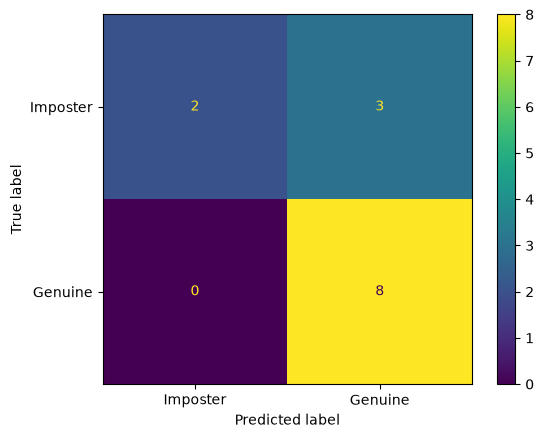

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

actual = df["Ground Truth"].str.strip().str.lower().map({
    "imposter": 0,
    "genuine": 1
})

predicted = df["Prediction"].str.strip().str.lower().map({
    "no match": 0,
    "match": 1
})

cm = confusion_matrix(
    actual,
    predicted,
    labels=[0, 1]
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Imposter", "Genuine"]
)

disp.plot()

There is overlap.

That is why those impostors are getting accepted.



### X-axis — Face Distance

This is the **distance calculated by our face verification code**.

For every test, we get one number:

```text
0.29
0.31
0.50
0.5669
0.58
0.69
...
```

That number tells us **how different the two face embeddings are**.

* **Lower distance → faces are more similar**
* **Higher distance → faces are more different**

So:

```text
0.23  → very similar
0.30  → similar
0.50  → somewhat similar
0.69  → more different
```

That's why **Face Distance is on the X-axis**: we're seeing where each test falls according to its distance.

---

### Y-axis — Number of Tests

This simply counts **how many tests have a distance in a particular range**.

For example, imagine our tests gave:

```text
0.23
0.26
0.29
0.31
0.40
0.49
0.50
0.56
0.58
0.61
0.69
```

The histogram groups these distances into ranges.

If the graph shows:

```text
       ███
       ███
       ███
       ███
       ███
       ███
-------------------------
       0.2   0.3   0.4
```

and the height is **3**, that means:

> **3 tests had distances within that particular range.**

So **Y-axis is NOT face distance**.

It is simply:

> **How many of our test cases fall into that distance range.**

---

### Think of the graph like this

**X-axis asks:**

> "What face distance did we get?"

**Y-axis asks:**

> "How many tests got a distance around there?"

So when you see a blue bar at around **0.25** with height **2**, it means:

> **There were 2 genuine tests whose face distances were around 0.25.**

And an orange bar around **0.55** with height **1** means:

> **There was 1 impostor test whose face distance was around 0.55.**

That's the whole meaning of the two axes.


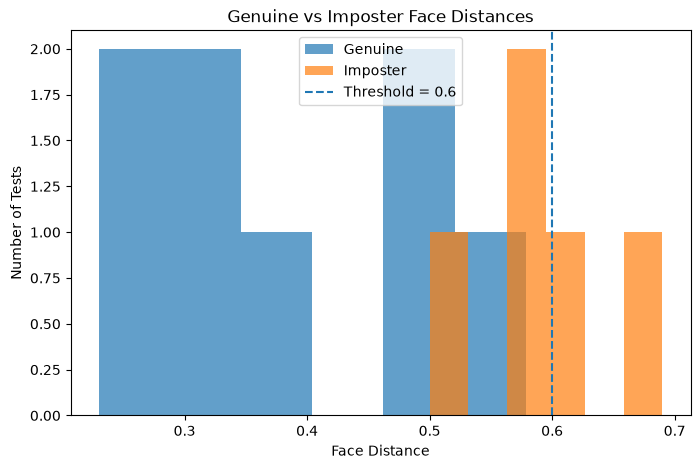

In [16]:
genuine = df.loc[
    df["Ground Truth"].str.strip().str.lower() == "genuine",
    "Distance"
]

imposter = df.loc[
    df["Ground Truth"].str.strip().str.lower() == "imposter",
    "Distance"
]

plt.figure(figsize=(8, 5))

plt.hist(genuine, bins=6, alpha=0.7, label="Genuine")
plt.hist(imposter, bins=6, alpha=0.7, label="Imposter")

plt.axvline(
    0.6,
    linestyle="--",
    label="Threshold = 0.6"
)

plt.xlabel("Face Distance")
plt.ylabel("Number of Tests")
plt.title("Genuine vs Imposter Face Distances")
plt.legend()
plt.show()

**Define Threshold Range**

```python
thresholds = np.round(np.arange(0.20, 0.81, 0.01), 2)

```

Generates a list of decision boundaries from `0.20` to `0.80` in steps of `0.01` (e.g., `0.20, 0.21, 0.22...`), rounding them to avoid float precision bugs.

---

**Initialize Main Results Storage**

```python
threshold_results = []

```

Creates an empty list to store the evaluation metrics (TP, FP, TN, FN, FAR, FRR) calculated for every single threshold.

---

**Loop Through Each Threshold**

```python
for threshold in thresholds:

```

Starts a loop to test the dataset performance against one specific numerical threshold at a time.

---

**Vectorized Prediction Generation**

```python
    predictions = np.where(
        df["Distance"] < threshold,
        "match",
        "no match"
    )

```

Compares all values in the `"Distance"` column against the current threshold. If the distance is smaller than the threshold, it outputs `"match"`; otherwise, it outputs `"no match"`.

---

**Initialize Temporary Batch Storage**

```python
    temp_results = []

```

Creates a fresh, empty list to hold the raw classification labels (`TP`, `TN`, `FP`, `FN`) for the current threshold's predictions.

---

**Pairwise Comparisons Loop**

```python
    for ground_truth, prediction in zip(
        df["Ground Truth"],
        predictions
    ):

```

Pairs up each true label from `df["Ground Truth"]` with its corresponding prediction for row-by-row inspection.

---

**Normalize Text Data**

```python
        ground_truth = str(ground_truth).strip().lower()
        prediction = str(prediction).strip().lower()

```

Converts string values to lowercase and removes accidental leading or trailing spaces to avoid string comparison errors (e.g., `"Genuine "` matching `"genuine"`).

---

**Classify True Positives (TP)**

```python
        if ground_truth == "genuine" and prediction == "match":
            temp_results.append("TP")

```

If the sample is actually genuine and the model correctly predicted a match, record it as a **True Positive**.

---

**Classify False Negatives (FN)**

```python
        elif ground_truth == "genuine" and prediction == "no match":
            temp_results.append("FN")

```

If the sample is genuine but the model wrongly rejected it, record it as a **False Negative**.

---

**Classify False Positives (FP)**

```python
        elif ground_truth == "imposter" and prediction == "match":
            temp_results.append("FP")

```

If the sample is an imposter but the model wrongly accepted it, record it as a **False Positive**.

---

**Classify True Negatives (TN)**

```python
        elif ground_truth == "imposter" and prediction == "no match":
            temp_results.append("TN")

```

If the sample is an imposter and the model correctly rejected it, record it as a **True Negative**.

---

**Tally Classification Totals**

```python
    tp = temp_results.count("TP")
    tn = temp_results.count("TN")
    fp = temp_results.count("FP")
    fn = temp_results.count("FN")

```

Counts the total instances of `TP`, `TN`, `FP`, and `FN` produced for this specific threshold.

---

**Calculate False Acceptance Rate (FAR)**

```python
    current_far = fp / (fp + tn) if (fp + tn) > 0 else 0

```

Calculates FAR ($\frac{\text{FP}}{\text{FP} + \text{TN}}$)—the percentage of imposters incorrectly allowed in. Uses a fallback to `0` to prevent division-by-zero errors.

---

**Calculate False Reject Rate (FRR)**

```python
    current_frr = fn / (fn + tp) if (fn + tp) > 0 else 0

```

Calculates FRR ($\frac{\text{FN}}{\text{FN} + \text{TP}}$)—the percentage of genuine users incorrectly locked out. Uses a fallback to `0` to prevent division-by-zero errors.

---

**Append Summary Dictionary**

```python
    threshold_results.append({
        "Threshold": round(threshold, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "FAR": current_far,
        "FRR": current_frr
    })

```

Saves all calculated metrics for the current threshold as a structured dictionary inside `threshold_results`.

---

**Build Final Summary DataFrame**

```python
threshold_df = pd.DataFrame(threshold_results)

```

Converts the collected list of dictionaries into a clean Pandas DataFrame for tabular analysis and plotting.

---

**Display Results**

```python
threshold_df

```

Prints the final metrics DataFrame directly in the Jupyter Notebook interface.

np.where() is a powerful function from the NumPy library that acts like a fast, vectorized "if-else" statement for arrays. “The numpy.where function is a computationally efficient way to apply if-else and conditional statements across NumPy arrays, which is significantly faster than using loops.” -- [YouTube]. [1] (https://numpy.org/doc/2.5/reference/generated/numpy.where.html)It has two completely different use cases depending on how many arguments you pass to it: [1] (https://www.stratascratch.com/blog/exploring-numpy-where-in-python), [2] (https://www.youtube.com/watch?v=oTf-C-jvU_k)Three Arguments (condition, x, y): Used to replace or update values based on a rule.One Argument (condition): Used to find the address positions (indices) where a rule is true. [1] (https://www.youtube.com/watch?v=jn6hSoMuYxo&t=6), [2] (https://www.youtube.com/watch?v=oTf-C-jvU_k)

In [17]:
thresholds = np.arange(0.20, 0.81, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = np.where(
        df["Distance"] < threshold,
        "match",
        "no match"
    )

    temp_results = []

    for ground_truth, prediction in zip(
        df["Ground Truth"],
        predictions
    ):
        ground_truth = str(ground_truth).strip().lower()
        prediction = str(prediction).strip().lower()

        if ground_truth == "genuine" and prediction == "match":
            temp_results.append("TP")

        elif ground_truth == "genuine" and prediction == "no match":
            temp_results.append("FN")

        elif ground_truth == "imposter" and prediction == "match":
            temp_results.append("FP")

        elif ground_truth == "imposter" and prediction == "no match":
            temp_results.append("TN")

    tp = temp_results.count("TP")
    tn = temp_results.count("TN")
    fp = temp_results.count("FP")
    fn = temp_results.count("FN")

    current_far = fp / (fp + tn) if (fp + tn) > 0 else 0
    current_frr = fn / (fn + tp) if (fn + tp) > 0 else 0

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "FAR": current_far,
        "FRR": current_frr
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,TP,TN,FP,FN,FAR,FRR
0,0.20,0,5,0,8,0.0,1.000
1,0.21,0,5,0,8,0.0,1.000
2,0.22,0,5,0,8,0.0,1.000
3,0.23,1,5,0,7,0.0,0.875
4,0.24,1,5,0,7,0.0,0.875
...,...,...,...,...,...,...,...
57,0.77,8,0,5,0,1.0,0.000
58,0.78,8,0,5,0,1.0,0.000
59,0.79,8,0,5,0,1.0,0.000
60,0.80,8,0,5,0,1.0,0.000


In [18]:
threshold_df.to_excel('my_data.xlsx', index=False)


### What are the X and Y axes?

**X-axis = Threshold**

We are testing different face-distance thresholds:

```text
0.20 → 0.21 → 0.22 → ... → 0.60 → ... → 0.80
```

Remember our rule:

> **Distance < Threshold → Match**

So the threshold is basically the **cutoff point** for deciding Match vs No Match.

**Y-axis = Rate**

This shows the proportion of errors:

* **0.0 = 0%**
* **0.2 = 20%**
* **0.5 = 50%**
* **1.0 = 100%**

---

### 🔵 Blue line = FAR

**FAR = False Acceptance Rate**

It answers:

> **"Out of all the impostors, how many did we incorrectly accept as genuine?"**

In your dataset there are **5 impostor tests**.

At threshold **0.60**:

* 3 impostors were incorrectly accepted
* 2 impostors were correctly rejected

So:

**FAR = 3/5 = 60%**

That's why the blue line is at **0.6 around threshold 0.60**.

---

### 🟠 Orange line = FRR

**FRR = False Rejection Rate**

It answers:

> **"Out of all the genuine people, how many did we incorrectly reject?"**

You have **8 genuine tests**.

At threshold **0.60**:

* 8 genuine → accepted
* 0 genuine → rejected

So:

**FRR = 0/8 = 0%**

That's why the orange line reaches **0 at threshold 0.60**.

---

### Why do the lines move in opposite directions?

This is the **most important thing about the graph**.

As we increase the threshold:

```text
Threshold ↑
```

we become more willing to call something a **Match**.

For example:

```text
Threshold = 0.4
Distance = 0.45

0.45 < 0.4 ❌
→ No Match
```

But:

```text
Threshold = 0.6
Distance = 0.45

0.45 < 0.6 ✅
→ Match
```

So increasing the threshold means **more people get accepted**.

That causes:

### FAR 🔵 to increase

More impostors can accidentally be accepted.

### FRR 🟠 to decrease

Fewer genuine people are rejected.

---

### Your graph at 0.60

The dashed line shows our current threshold:

**0.60**

At that point:

```text
FAR = 0.60 → 60%
FRR = 0.00 → 0%
```

Meaning:

> We are accepting all genuine cases, but we're also incorrectly accepting **60% of the impostor cases in this tiny dataset**.

🚨 That's a major security problem **in this toy/development dataset**.

And this is exactly why we're doing threshold evaluation instead of simply assuming **0.6 is good because dlib's example uses it**.

### The big takeaway

Think of the threshold as a **door sensitivity setting**:

```text
LOW threshold
     ↓
Strict door
     ↓
Harder to get accepted
     ↓
FAR ↓
FRR ↑


HIGH threshold
     ↓
Lenient door
     ↓
Easier to get accepted
     ↓
FAR ↑
FRR ↓
```




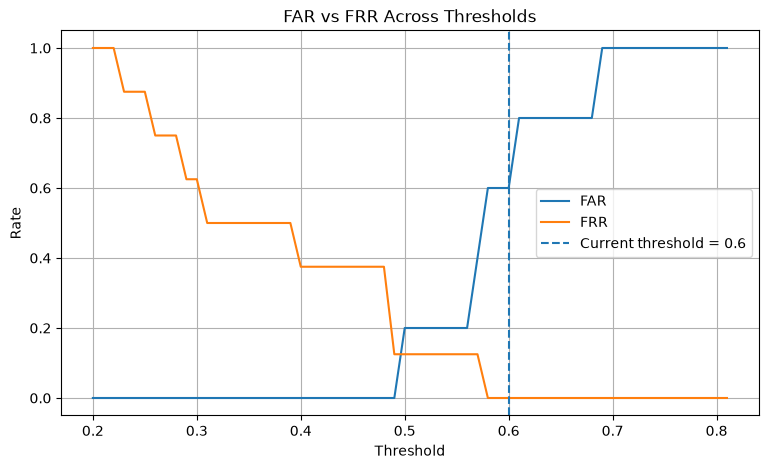

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["FAR"],
    label="FAR"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["FRR"],
    label="FRR"
)

plt.axvline(
    0.6,
    linestyle="--",
    label="Current threshold = 0.6"
)

plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("FAR vs FRR Across Thresholds")
plt.legend()
plt.grid(True)
plt.show()

**Calculate Absolute Difference Between FAR and FRR**

```python
threshold_df["FAR_FRR_Difference"] = (
    threshold_df["FAR"] - threshold_df["FRR"]
).abs()

```

Subtracts the **False Reject Rate (FRR)** from the **False Acceptance Rate (FAR)** for every threshold row, then uses `.abs()` to take the absolute value. This measures how close FAR and FRR are to each other regardless of which one is higher (a value close to `0` means FAR and FRR are nearly equal, which corresponds to the **Equal Error Rate / EER** point).

---

**Locate the Row with the Smallest Difference**

```python
best_balance = threshold_df.loc[
    threshold_df["FAR_FRR_Difference"].idxmin()
]

```

* **`threshold_df["FAR_FRR_Difference"].idxmin()`**: Finds the index position (row number) where the difference between FAR and FRR is at its absolute minimum.
* **`threshold_df.loc[...]`**: Extracts that specific row's entire set of metrics (Threshold, TP, TN, FP, FN, FAR, FRR) from the DataFrame as a Pandas Series.

---

**Display Optimal Threshold Metrics**

```python
best_balance

```

Prints the extracted row containing the threshold that achieves the best balance between security (low FAR) and user convenience (low FRR).

In [19]:
threshold_df["FAR_FRR_Difference"] = (
    threshold_df["FAR"] - threshold_df["FRR"]
).abs()

best_balance = threshold_df.loc[
    threshold_df["FAR_FRR_Difference"].idxmin()
]

best_balance

Threshold             0.500
TP                    7.000
TN                    4.000
FP                    1.000
FN                    1.000
FAR                   0.200
FRR                   0.125
FAR_FRR_Difference    0.075
Name: 30, dtype: float64

Here is a concrete example showing what the `fpr`, `tpr`, and `roc_thresholds` variables actually store after running `roc_curve`:

**1. Sample Input Data**
Suppose you have 4 test samples:

```python
# Answer key: 1 = Genuine, 0 = Imposter
y_true = [1, 1, 0, 0] 

# Negated distances (higher means more similar)
similarity_score = [-0.10, -0.40, -0.35, -0.80] 

```

---

**2. What `roc_curve` Outputs**

`roc_curve` tests various score cutoffs to see how many genuine users get accepted (**TPR**) vs. how many imposters get accidentally accepted (**FPR**).

```python
fpr, tpr, roc_thresholds = roc_curve(y_true, similarity_score)

```

If you print the variables, they look like this:

* **`fpr` (False Positive Rates):** `[0.0, 0.0, 0.5, 0.5, 1.0]`
* **`tpr` (True Positive Rates):** `[0.0, 0.5, 0.5, 1.0, 1.0]`
* **`roc_thresholds`:** `[inf, -0.10, -0.35, -0.40, -0.80]`

---

**3. What Each Value Represents**

| Threshold Cutoff | What gets accepted? | TPR (Genuine accepted) | FPR (Imposters allowed) |
| --- | --- | --- | --- |
| **`inf`** | Nothing is accepted | `0.0` (0 out of 2) | `0.0` (0 out of 2) |
| **`-0.10`** | Only sample with score $\ge -0.10$ | `0.5` (1 out of 2) | `0.0` (0 out of 2) |
| **`-0.35`** | Samples with score $\ge -0.35$ | `0.5` (1 out of 2) | `0.5` (1 out of 2) |
| **`-0.40`** | Samples with score $\ge -0.40$ | `1.0` (2 out of 2) | `0.5` (1 out of 2) |
| **`-0.80`** | Everything is accepted | `1.0` (2 out of 2) | `1.0` (2 out of 2) |

*(Note: Scikit-learn automatically adds `inf` as the starting threshold so the ROC curve always begins at the origin point `(0,0)` on your plot).*

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = df["Ground Truth"].str.strip().str.lower().map({
    "imposter": 0,
    "genuine": 1
})

# Smaller distance = more similar
# Therefore use negative distance as the similarity score
similarity_score = -df["Distance"]

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    similarity_score
)

auc_score = roc_auc_score(
    y_true,
    similarity_score
)

print(f"ROC AUC: {auc_score:.4f}")

ROC AUC: 0.9500


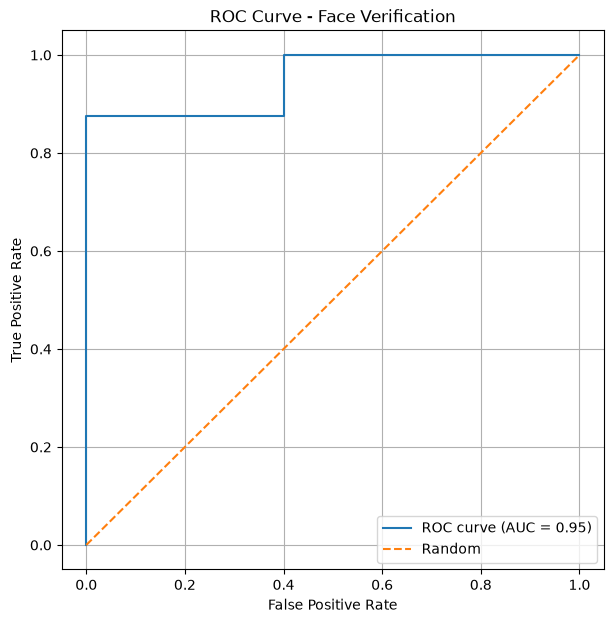

In [21]:
plt.figure(figsize=(7, 7))

plt.plot(
    fpr,
    tpr,
    label=f"ROC curve (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Face Verification")
plt.legend()
plt.grid(True)
plt.show()

Refering fp

In [23]:
false_positives = df[df["Result"] == "FP"]

false_positives[
    [
        "Test ID",
        "ID",
        "Video",
        "Ground Truth",
        "Distance",
        "Threshold",
        "Prediction"
    ]
]

,Test ID,ID,Video,Ground Truth,Distance,Threshold,Prediction
2,3,abhishek id,Aishwarya Video,Imposter,0.5669,0.6,match
4,5,abhishek id,mummy video,Imposter,0.5000,0.6,match
5,6,abhishek id,papa video,Imposter,0.5800,0.6,match


In [24]:
final_summary = pd.DataFrame({
    "Metric": [
        "Dataset Size",
        "Baseline Threshold",
        "TP",
        "TN",
        "FP",
        "FN",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "FAR",
        "FRR",
        "ROC AUC"
    ],
    "Value": [
        len(df),
        0.60,
        TP,
        TN,
        FP,
        FN,
        f"{accuracy:.2%}",
        f"{precision:.2%}",
        f"{recall:.2%}",
        f"{f1:.2%}",
        f"{far:.2%}",
        f"{frr:.2%}",
        f"{auc_score:.4f}"
    ]
})

final_summary

,Metric,Value
0,Dataset Size,13
1,Baseline Threshold,0.6
2,TP,8
3,TN,2
4,FP,3
5,FN,0
6,Accuracy,76.92%
7,Precision,72.73%
8,Recall,100.00%
9,F1 Score,84.21%


0.50 is our experimentally selected development threshold based on the current 13-sample evaluation dataset. It is not yet a production-calibrated threshold.

That's actually a good production-AI lesson: we're not blindly using the model's default 0.6—we evaluated our own data and made a deliberate threshold choice based on the security/UX trade-off.